# AudioCaps Raw Audio — Data Analysis
Analyze splits, filename matching, and audio features.

**Flow:** Extract & analyze train, val, test separately → then combine for overall analysis.

In [28]:
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 0. Load Data & Clean

In [29]:
AUDIO_DIR = '/home/hice1/hgupta312/scratch/audiocaps_raw_audio'
FILENAMES_CSV = 'outputs/filenames.csv'
TRAIN_CSV = 'data/train.csv'
TEST_CSV  = 'data/test.csv'
VAL_CSV   = 'data/val.csv'

filenames_df = pd.read_csv(FILENAMES_CSV)
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
val_df   = pd.read_csv(VAL_CSV)

# Fix malformed rows (captions with newlines that split across CSV lines)
train_df = train_df.dropna(subset=['youtube_id', 'start_time'])
train_df['start_time'] = train_df['start_time'].astype(int)

test_df = test_df.dropna(subset=['youtube_id', 'start_time'])
test_df['start_time'] = test_df['start_time'].astype(int)

val_df = val_df.dropna(subset=['youtube_id', 'start_time'])
val_df['start_time'] = val_df['start_time'].astype(int)

print(f'Filenames CSV rows : {len(filenames_df)}')
print(f'Train rows         : {len(train_df)}')
print(f'Test rows          : {len(test_df)}')
print(f'Val rows           : {len(val_df)}')

Filenames CSV rows : 101715
Train rows         : 91254
Test rows          : 4875
Val rows           : 2475


## 1. Count of Audio Files per Split

split  rows_in_csv
train        91254
  val         2475
 test         4875


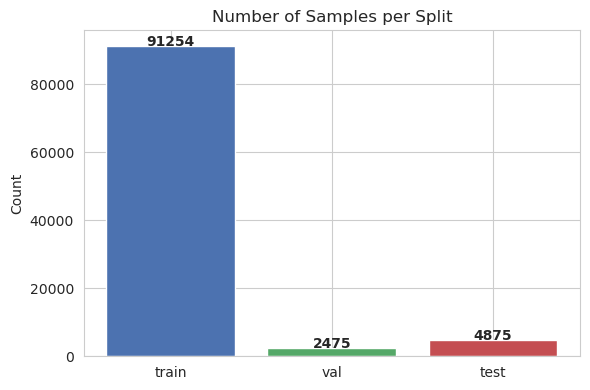

In [30]:
split_counts = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'rows_in_csv': [len(train_df), len(val_df), len(test_df)]
})
print(split_counts.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(split_counts['split'], split_counts['rows_in_csv'], color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylabel('Count')
ax.set_title('Number of Samples per Split')
for i, v in enumerate(split_counts['rows_in_csv']):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Unique Counts

In [31]:
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'--- {name} ---')
    print(f'  Total rows           : {len(df)}')
    print(f'  Unique audiocap_id   : {df["audiocap_id"].nunique()}')
    print(f'  Unique youtube_id    : {df["youtube_id"].nunique()}')
    print(f'  Unique (yt, start)   : {df.groupby(["youtube_id","start_time"]).ngroups}')
    print(f'  Unique captions      : {df["caption"].nunique()}')
    print()

print(f'Unique filenames on disk: {filenames_df["filename"].nunique()} / {len(filenames_df)}')

--- train ---
  Total rows           : 91254
  Unique audiocap_id   : 91254
  Unique youtube_id    : 91254
  Unique (yt, start)   : 91254
  Unique captions      : 74676

--- val ---
  Total rows           : 2475
  Unique audiocap_id   : 2475
  Unique youtube_id    : 495
  Unique (yt, start)   : 495
  Unique captions      : 2311

--- test ---
  Total rows           : 4875
  Unique audiocap_id   : 4875
  Unique youtube_id    : 975
  Unique (yt, start)   : 975
  Unique captions      : 4636

Unique filenames on disk: 101715 / 101715


## 3. Match Raw Audio to Splits
Filenames follow the pattern: `{youtube_id}_{start_time}.wav`

In [32]:
def add_expected_filename(df):
    df = df.copy()
    df['expected_filename'] = df['youtube_id'] + '_' + df['start_time'].astype(str) + '.wav'
    return df

train_df = add_expected_filename(train_df)
test_df  = add_expected_filename(test_df)
val_df   = add_expected_filename(val_df)

disk_files = set(filenames_df['filename'].str.strip())

match_summary = []
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    unique_expected = df.drop_duplicates(subset=['youtube_id', 'start_time'])
    matched = unique_expected['expected_filename'].isin(disk_files).sum()
    total   = len(unique_expected)
    match_summary.append({'split': name, 'unique_clips': total, 'matched_on_disk': matched,
                          'missing': total - matched, 'match_pct': round(100*matched/total, 2)})

match_df = pd.DataFrame(match_summary)
print(match_df.to_string(index=False))

split  unique_clips  matched_on_disk  missing  match_pct
train         91254            91254        0      100.0
  val           495              495        0      100.0
 test           975              975        0      100.0


In [33]:
all_expected = set(
    pd.concat([train_df, test_df, val_df])['expected_filename'].unique()
)
orphan_files = disk_files - all_expected
print(f'Files on disk not in any split: {len(orphan_files)}')
if orphan_files:
    print('Examples:', list(orphan_files)[:10])

Files on disk not in any split: 8991
Examples: ['3bmkpZKUocw_30.wav', 'MYrQpgPWnk4_30.wav', 'OtDVd-1zaqU_30.wav', 'KtcaTFriCUI_30.wav', '-7n2lwXUzvM_30.m4a.part', 'Fc9v0QubqQ0_80.wav', 'NIlvyjh-zP8_50.wav', 'QNMz8C0uAuk_170.wav', 'I0uLqcIcgy8_280.wav', 'anFJAG7Me2o_90.wav']


## 4. Build per-split file lists (only files that exist on disk)

In [34]:
split_file_lists = {}
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    expected = set(df['expected_filename'].unique())
    on_disk = list(expected & disk_files)
    split_file_lists[split_name] = on_disk
    print(f'{split_name}: {len(on_disk)} unique audio files on disk')

train: 91254 unique audio files on disk
val: 495 unique audio files on disk
test: 975 unique audio files on disk


## 5. Feature Extraction Helper

In [35]:
def extract_features(file_list, audio_dir, desc='Extracting'):
    """Extract lightweight audio features for a list of files."""
    records = []
    for fname in tqdm(file_list, desc=desc):
        fpath = os.path.join(audio_dir, fname)
        if not os.path.isfile(fpath):
            records.append({'filename': fname, 'error': 'file_not_found'})
            continue
        try:
            y, sr = librosa.load(fpath, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)
            rms = float(np.sqrt(np.mean(y**2)))
            zcr = float(np.mean(librosa.feature.zero_crossing_rate(y)))
            spec_cent = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
            spec_bw   = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
            spec_roll = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))
            records.append({
                'filename': fname,
                'sample_rate': sr,
                'duration_sec': round(duration, 3),
                'num_samples': len(y),
                'rms_energy': round(rms, 6),
                'zero_crossing_rate': round(zcr, 6),
                'spectral_centroid': round(spec_cent, 2),
                'spectral_bandwidth': round(spec_bw, 2),
                'spectral_rolloff': round(spec_roll, 2)
            })
        except Exception as e:
            records.append({'filename': fname, 'error': str(e)})
    df = pd.DataFrame(records)
    return df


FEAT_COLS = ['duration_sec', 'rms_energy', 'zero_crossing_rate',
             'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff']

FEAT_TITLES = ['Duration (sec)', 'RMS Energy', 'Zero Crossing Rate',
               'Spectral Centroid (Hz)', 'Spectral Bandwidth (Hz)', 'Spectral Rolloff (Hz)']

In [36]:
def analyze_split(df_audio, split_name, color='steelblue'):
    """Print stats & plot histograms for one split."""
    valid = df_audio[df_audio['duration_sec'].notna()].copy()
    errors = df_audio[df_audio['duration_sec'].isna()]
    
    print(f'=== {split_name.upper()} ===')
    print(f'  Successfully loaded : {len(valid)}')
    print(f'  Errors              : {len(errors)}')
    print(f'  Mode sample rate    : {valid["sample_rate"].mode().values}')
    
    short = valid[valid['duration_sec'] < 1]
    silent = valid[valid['rms_energy'] < 1e-5]
    print(f'  Clips < 1 sec       : {len(short)}')
    print(f'  Near-silent         : {len(silent)}')
    print()
    print(valid[FEAT_COLS].describe().round(4).to_string())
    print()
    
    # Histograms
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, col, title in zip(axes.flat, FEAT_COLS, FEAT_TITLES):
        ax.hist(valid[col], bins=50, color=color, edgecolor='white')
        ax.set_title(title)
        ax.axvline(valid[col].median(), color='red', ls='--', lw=1, label='median')
        ax.legend(fontsize=8)
    plt.suptitle(f'{split_name.upper()} — Feature Distributions (n={len(valid)})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(valid[FEAT_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
    ax.set_title(f'{split_name.upper()} — Feature Correlations')
    plt.tight_layout()
    plt.show()
    
    return valid

---
## 6. Train Split — Extract & Analyze

In [38]:
# Sample up to N files for audio analysis
SAMPLE_FRACTION = 0.1  # Adjust this fraction to sample more or fewer files

N_SAMPLE_TRAIN = int(0.05 * len(split_file_lists['train']))  # increase if you have time
N_SAMPLE_TEST = int(0.5 * len(split_file_lists['test']))  # increase if you have time
N_SAMPLE_VAL = int(0.5 * len(split_file_lists['val']))  # increase if you have time

print(f'Sampling {N_SAMPLE_TRAIN} from train, {N_SAMPLE_TEST} from test, {N_SAMPLE_VAL} from val for analysis.')

#all_files = list(disk_files)
np.random.seed(42)
sample_files_train = np.random.choice(split_file_lists['train'], size=min(N_SAMPLE_TRAIN, len(split_file_lists['train'])), replace=False)
sample_files_test = np.random.choice(split_file_lists['test'], size=min(N_SAMPLE_TEST, len(split_file_lists['test'])), replace=False)
sample_files_val = np.random.choice(split_file_lists['val'], size=min(N_SAMPLE_VAL, len(split_file_lists['val'])), replace=False)

Sampling 4562 from train, 487 from test, 247 from val for analysis.


Train: 100%|██████████| 4562/4562 [04:59<00:00, 15.25it/s]


=== TRAIN ===
  Successfully loaded : 4562
  Errors              : 0
  Mode sample rate    : [22050]
  Clips < 1 sec       : 0
  Near-silent         : 0

       duration_sec  rms_energy  zero_crossing_rate  spectral_centroid  spectral_bandwidth  spectral_rolloff
count     4562.0000   4562.0000           4562.0000          4562.0000           4562.0000         4562.0000
mean         9.8649      0.1005              0.1549          2489.3271           2138.8516         4749.2579
std          0.6227      0.0916              0.0942          1018.6329            611.3563         1835.8252
min          2.0500      0.0008              0.0000           165.2000             92.0900          233.9400
25%         10.0000      0.0361              0.0909          1745.1525           1702.2425         3309.7100
50%         10.0000      0.0776              0.1346          2374.3250           2230.8200         4663.7900
75%         10.0000      0.1377              0.1973          3101.1425           26

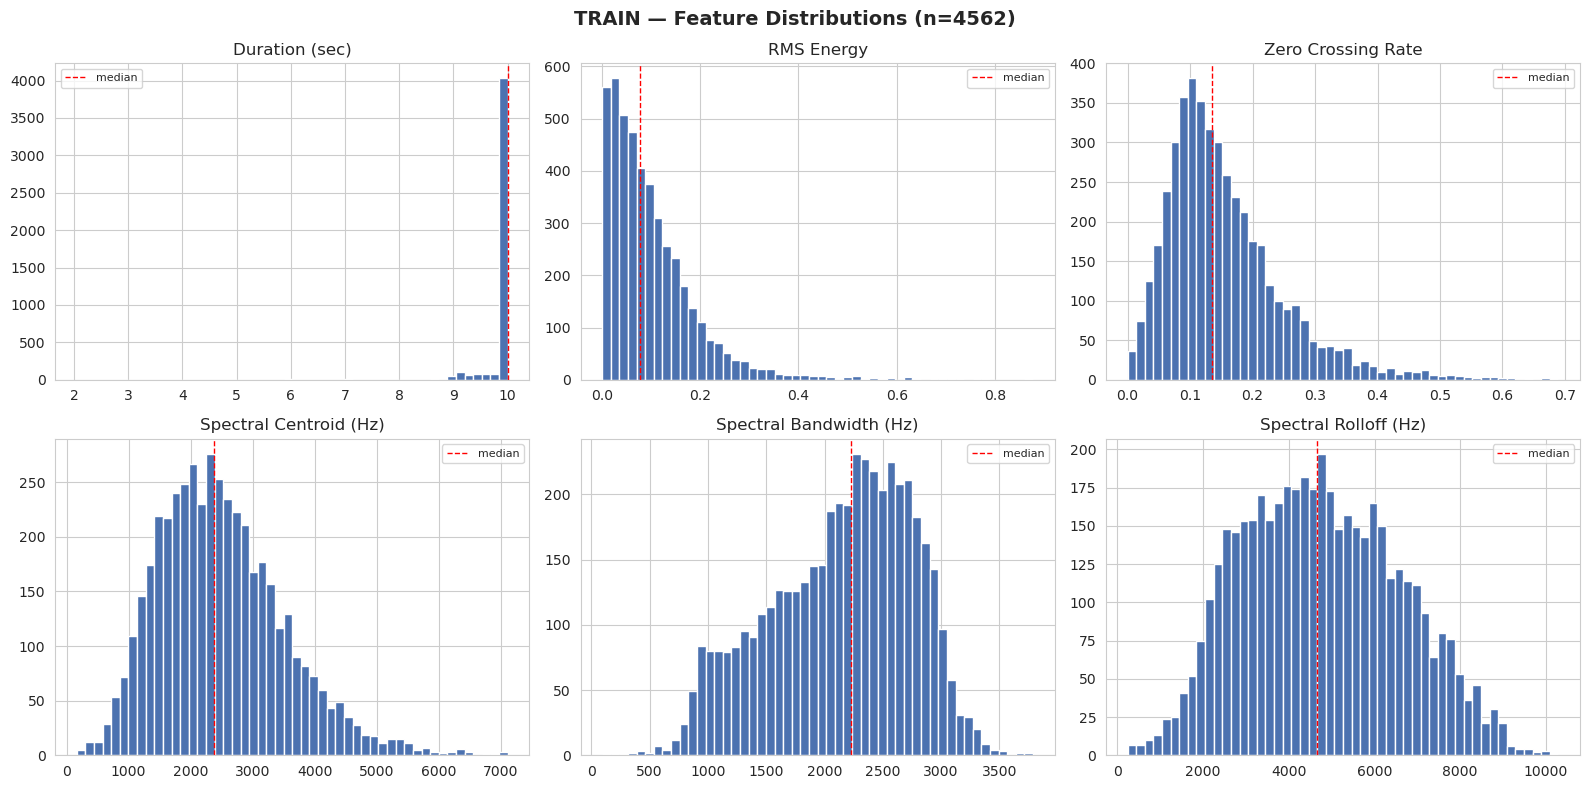

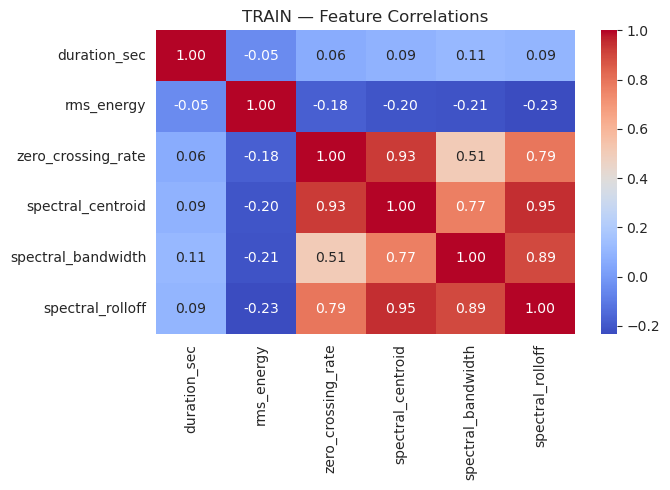

In [39]:
train_audio = extract_features(sample_files_train, AUDIO_DIR, desc='Train')
train_audio['split'] = 'train'
train_valid = analyze_split(train_audio, 'train', color='#4C72B0')

## 7. Val Split — Extract & Analyze

Val: 100%|██████████| 247/247 [00:15<00:00, 15.81it/s]


=== VAL ===
  Successfully loaded : 247
  Errors              : 0
  Mode sample rate    : [22050]
  Clips < 1 sec       : 0
  Near-silent         : 0

       duration_sec  rms_energy  zero_crossing_rate  spectral_centroid  spectral_bandwidth  spectral_rolloff
count      247.0000    247.0000            247.0000           247.0000            247.0000          247.0000
mean         9.8779      0.1009              0.1536          2487.6061           2153.1242         4760.6329
std          0.5002      0.0919              0.0921          1011.4706            598.9158         1811.3720
min          5.1080      0.0010              0.0195           381.2400            409.7300          711.9900
25%         10.0000      0.0368              0.0867          1667.0950           1744.0200         3258.8850
50%         10.0000      0.0729              0.1364          2323.8500           2205.9400         4596.5100
75%         10.0000      0.1356              0.1992          3124.2650           2624.

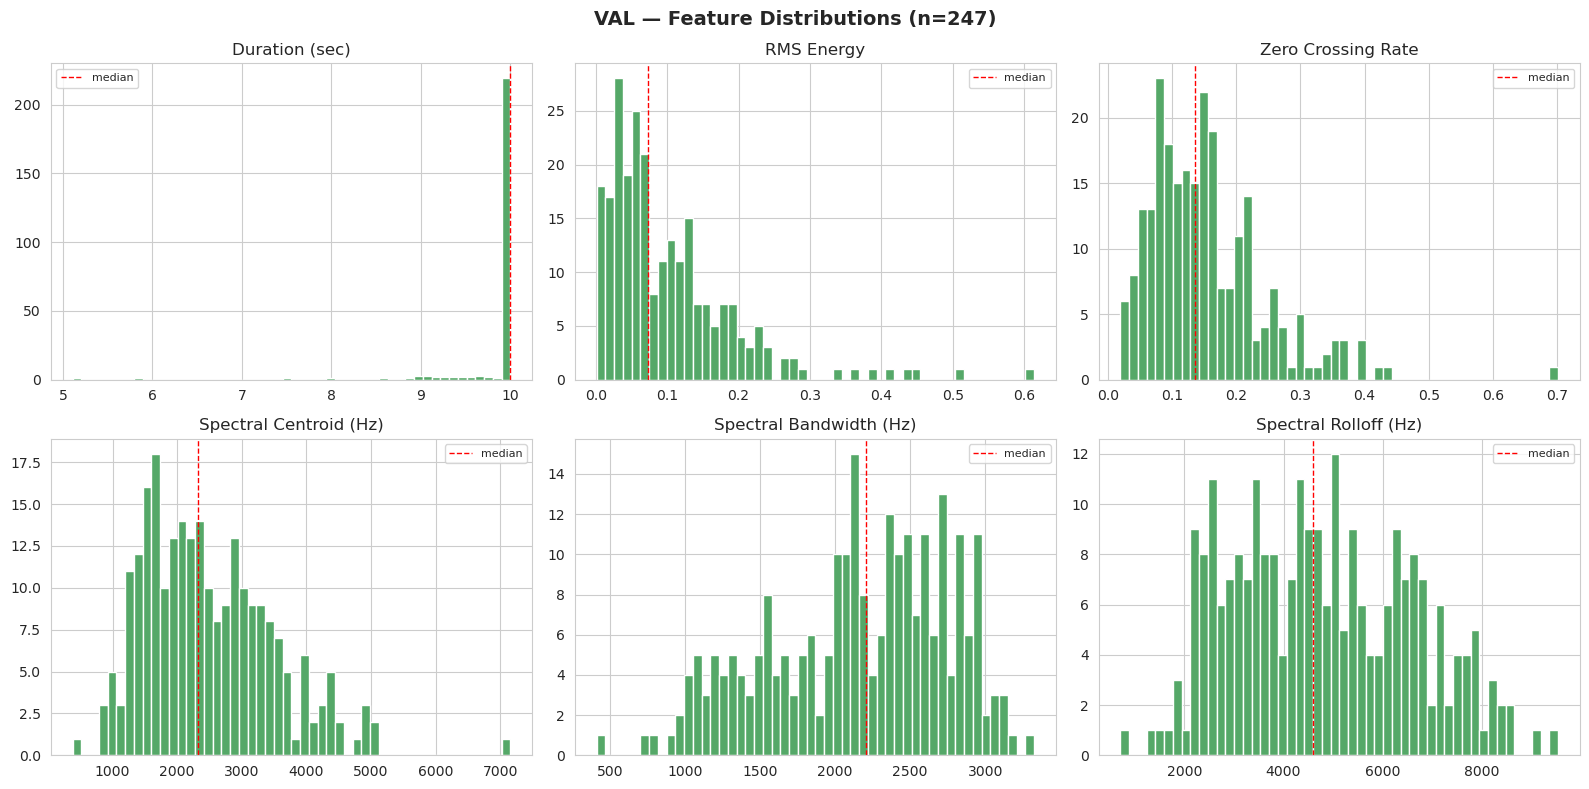

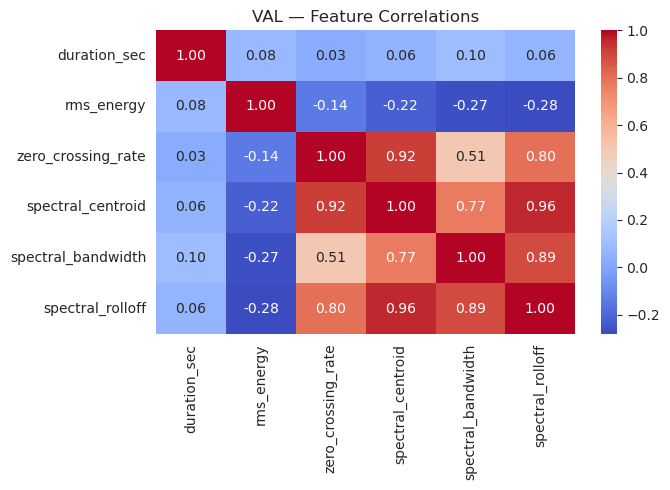

In [40]:
val_audio = extract_features(sample_files_val, AUDIO_DIR, desc='Val')
val_audio['split'] = 'val'
val_valid = analyze_split(val_audio, 'val', color='#55A868')

## 8. Test Split — Extract & Analyze

Test: 100%|██████████| 487/487 [00:31<00:00, 15.50it/s]


=== TEST ===
  Successfully loaded : 487
  Errors              : 0
  Mode sample rate    : [22050]
  Clips < 1 sec       : 0
  Near-silent         : 0

       duration_sec  rms_energy  zero_crossing_rate  spectral_centroid  spectral_bandwidth  spectral_rolloff
count      487.0000    487.0000            487.0000           487.0000            487.0000          487.0000
mean         9.8090      0.1049              0.1577          2511.8490           2115.4002         4766.7970
std          0.7848      0.0864              0.0978          1043.9776            606.1844         1823.4386
min          1.8340      0.0010              0.0152           378.6800            368.9000          464.4900
25%         10.0000      0.0427              0.0899          1778.3050           1659.0200         3448.8750
50%         10.0000      0.0838              0.1367          2359.2500           2196.0000         4642.3500
75%         10.0000      0.1440              0.1971          3101.9150           2599

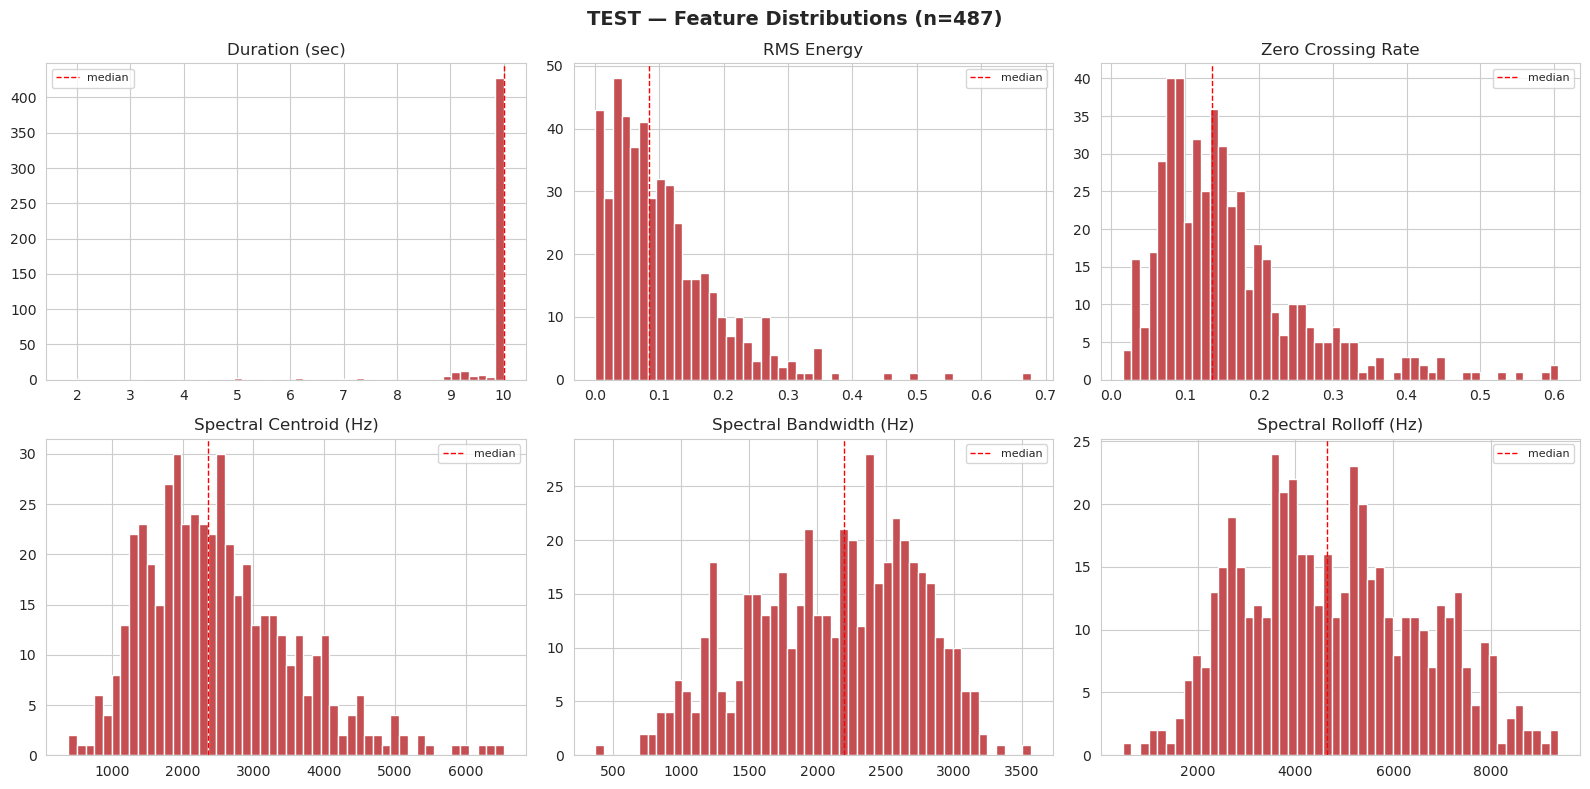

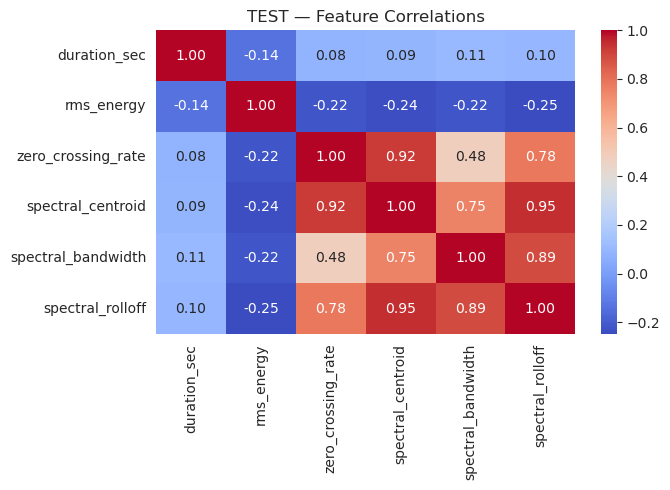

In [41]:
test_audio = extract_features(sample_files_test, AUDIO_DIR, desc='Test')
test_audio['split'] = 'test'
test_valid = analyze_split(test_audio, 'test', color='#C44E52')

---
## 9. Combined — All Splits Together

In [42]:
all_valid = pd.concat([train_valid, val_valid, test_valid], ignore_index=True)
print(f'Total valid audio files across all splits: {len(all_valid)}')
print(f'Split distribution:\n{all_valid["split"].value_counts().to_string()}')
print()
print('=== ALL SPLITS COMBINED ===')
print(all_valid[FEAT_COLS].describe().round(4).to_string())

Total valid audio files across all splits: 5296
Split distribution:
split
train    4562
test      487
val       247

=== ALL SPLITS COMBINED ===
       duration_sec  rms_energy  zero_crossing_rate  spectral_centroid  spectral_bandwidth  spectral_rolloff
count     5296.0000   5296.0000           5296.0000          5296.0000           5296.0000         5296.0000
mean         9.8603      0.1009              0.1551          2491.3179           2137.3607         4751.4013
std          0.6344      0.0911              0.0944          1020.4835            610.2424         1833.2232
min          1.8340      0.0008              0.0000           165.2000             92.0900          233.9400
25%         10.0000      0.0366              0.0906          1744.8600           1698.7175         3316.5800
50%         10.0000      0.0778              0.1348          2372.1150           2227.2500         4656.8150
75%         10.0000      0.1380              0.1975          3103.3725           2613.6975  

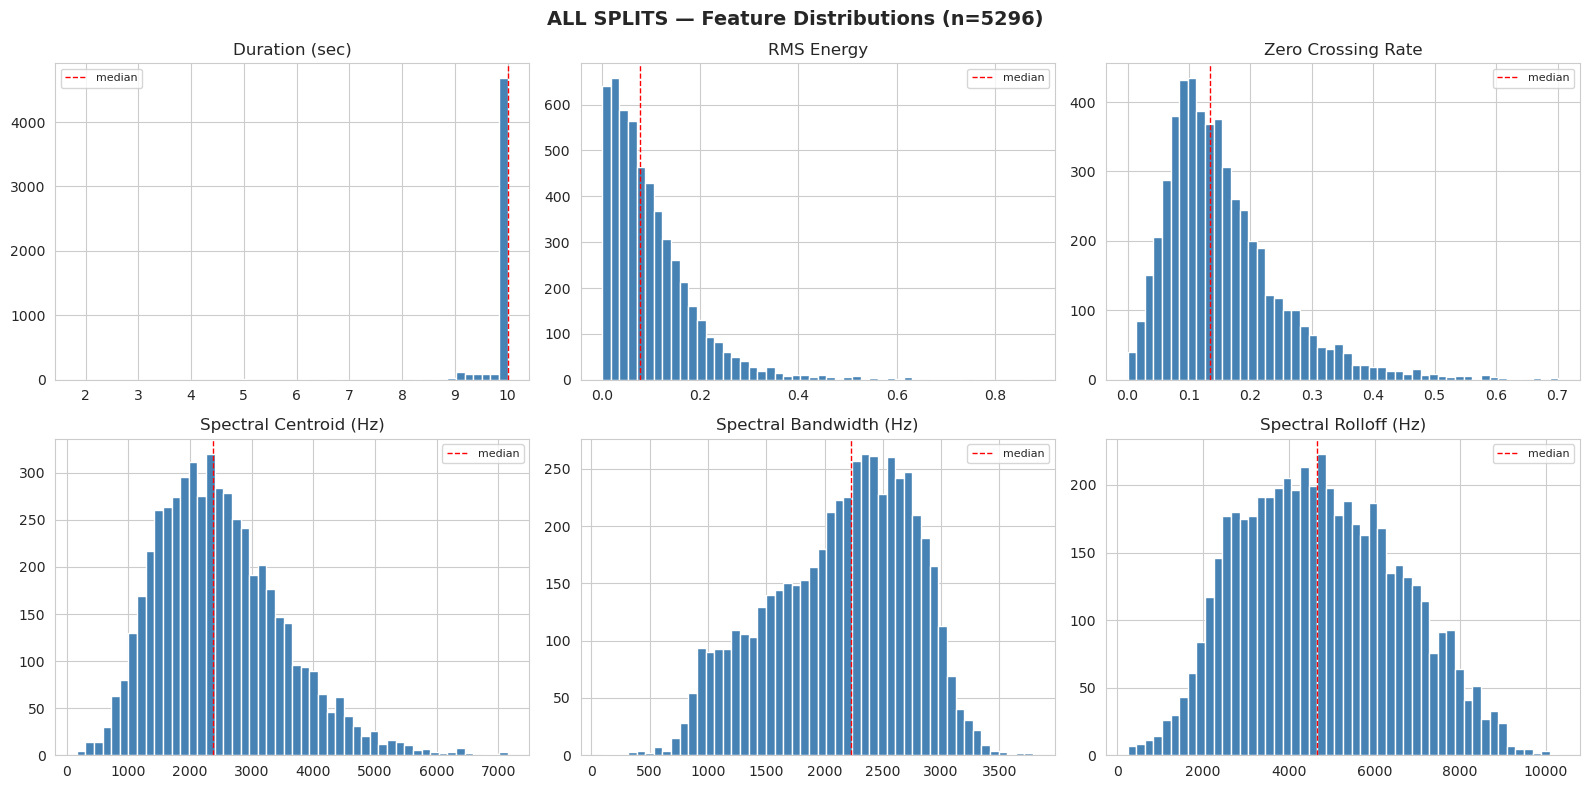

In [43]:
# Combined histograms — all files
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col, title in zip(axes.flat, FEAT_COLS, FEAT_TITLES):
    ax.hist(all_valid[col], bins=50, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.axvline(all_valid[col].median(), color='red', ls='--', lw=1, label='median')
    ax.legend(fontsize=8)
plt.suptitle(f'ALL SPLITS — Feature Distributions (n={len(all_valid)})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

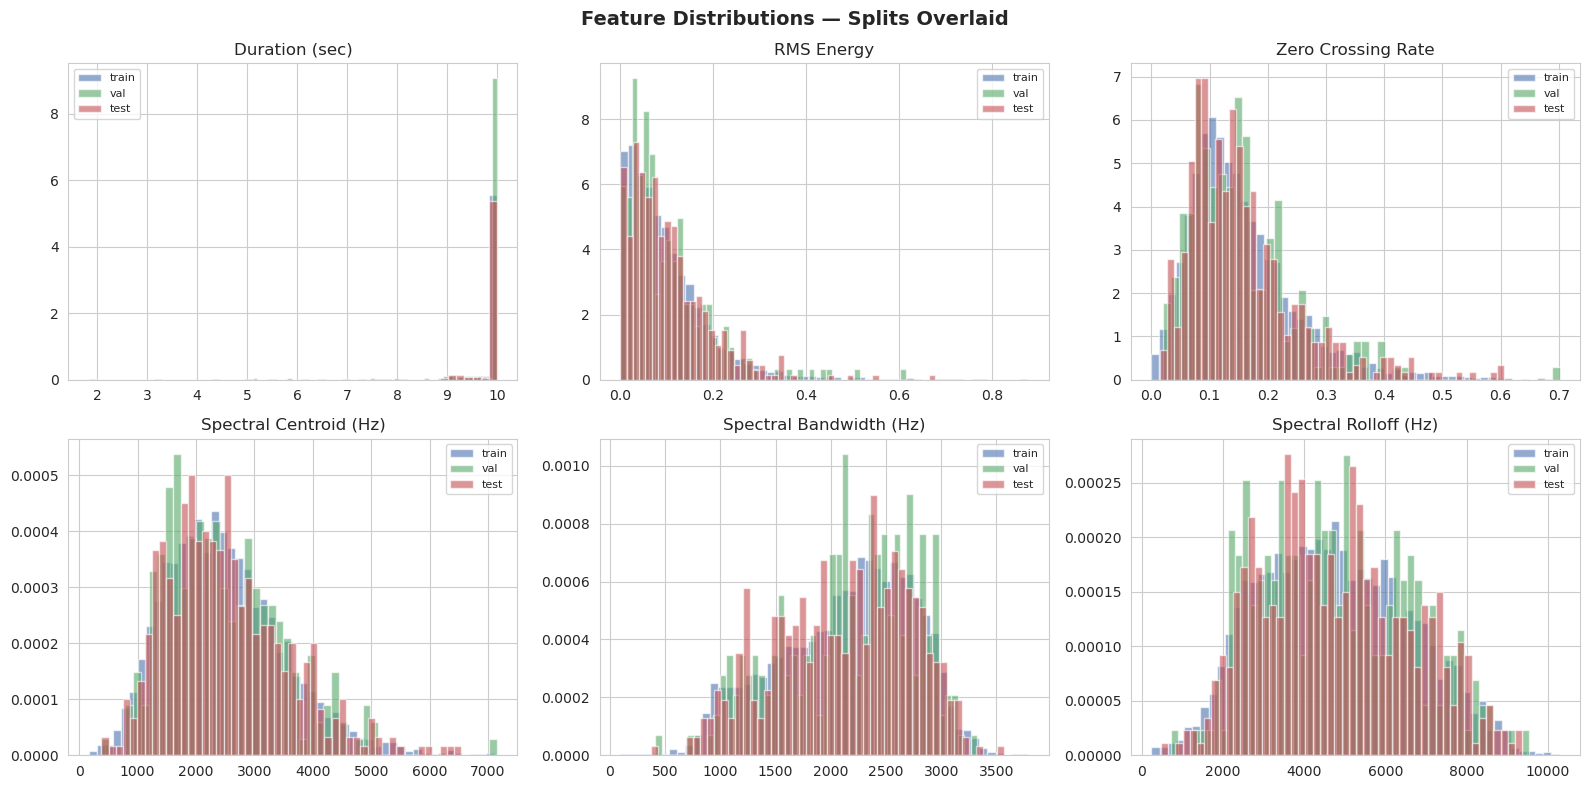

In [61]:
# Overlaid histograms — compare splits
split_colors = {'train': '#4C72B0', 'val': '#55A868', 'test': '#C44E52'}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col, title in zip(axes.flat, FEAT_COLS, FEAT_TITLES):
    for split, color in split_colors.items():
        subset = all_valid[all_valid['split'] == split]
        ax.hist(subset[col], bins = 50,alpha=0.6, label=split, color=color, edgecolor='white', histtype='bar', density=True, stacked=True)
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions — Splits Overlaid', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

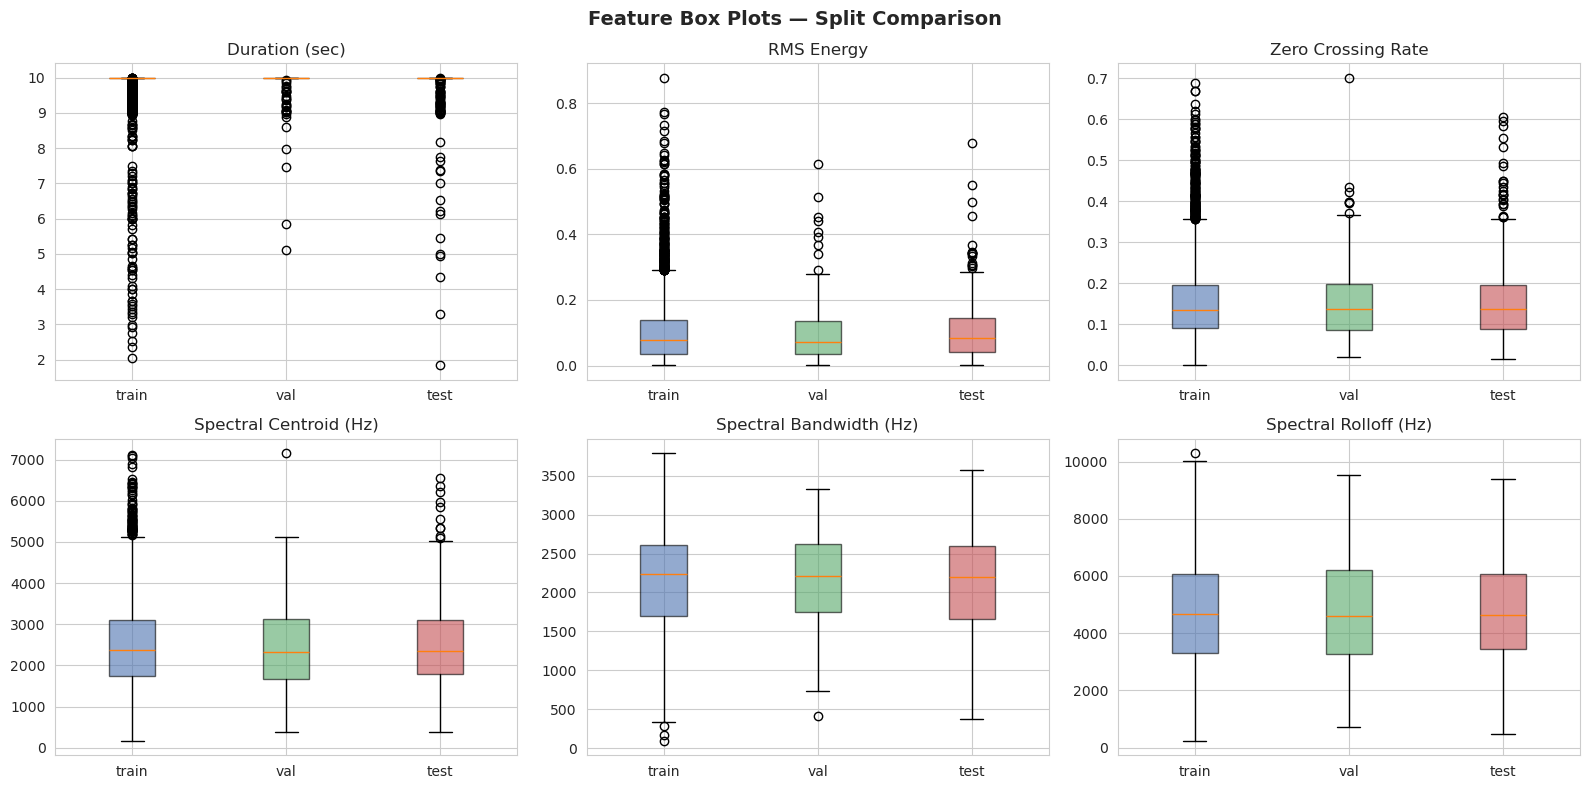

In [62]:
# Box plots — compare splits
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col, title in zip(axes.flat, FEAT_COLS, FEAT_TITLES):
    data = [all_valid[all_valid['split'] == s][col].dropna() for s in ['train', 'val', 'test']]
    bp = ax.boxplot(data, labels=['train', 'val', 'test'], patch_artist=True)
    for patch, color in zip(bp['boxes'], split_colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(title)
plt.suptitle('Feature Box Plots — Split Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

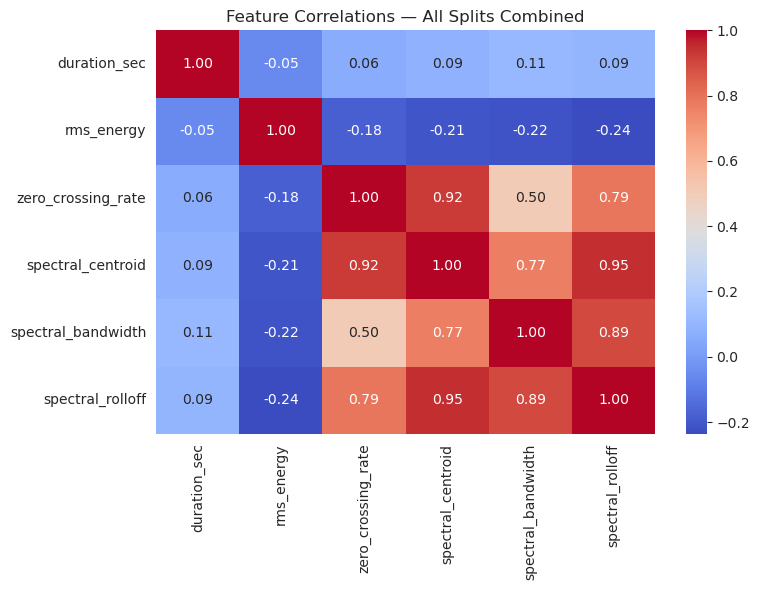

In [63]:
# Combined correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(all_valid[FEAT_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlations — All Splits Combined')
plt.tight_layout()
plt.show()

## 10. Caption Analytics

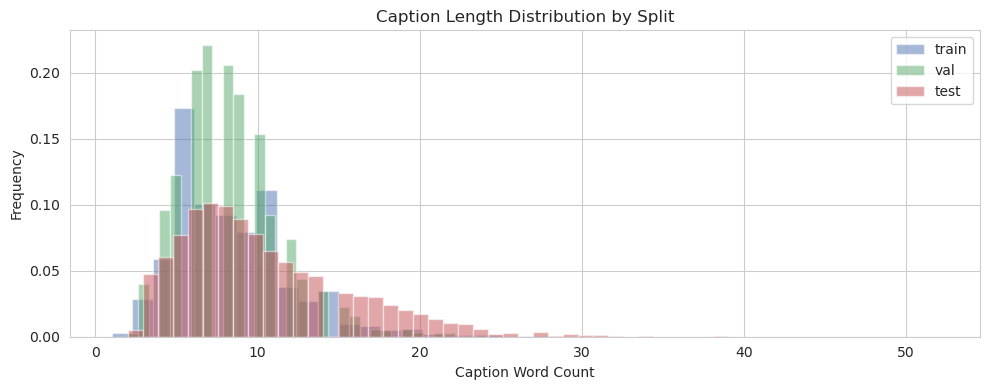

Caption word count stats:
  train: mean=8.4, median=8
  val: mean=8.3, median=8
  test: mean=10.3, median=9


In [66]:
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df['caption_word_count'] = df['caption'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 4))
for name, df, c in [('train', train_df, '#4C72B0'), ('val', val_df, '#55A868'), ('test', test_df, '#C44E52')]:
    ax.hist(df['caption_word_count'], bins=40, alpha=0.5, label=name, color=c, edgecolor='white', density=True, stacked=True)
ax.set_xlabel('Caption Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Caption Length Distribution by Split')
ax.legend()
plt.tight_layout()
plt.show()

print('Caption word count stats:')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: mean={df["caption_word_count"].mean():.1f}, median={df["caption_word_count"].median():.0f}')

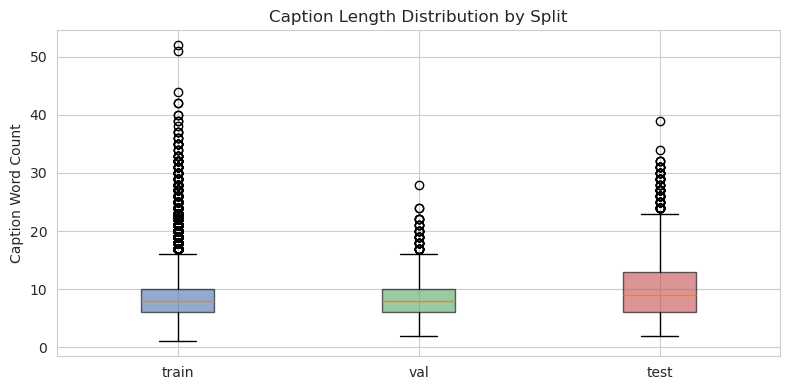

In [71]:
fig, ax = plt.subplots(figsize=(8, 4))
data = [train_df['caption_word_count'].dropna(), val_df['caption_word_count'].dropna(), test_df['caption_word_count'].dropna()]
bp = ax.boxplot(data, labels=['train', 'val', 'test'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#4C72B0', '#55A868', '#C44E52']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Caption Word Count')
ax.set_title('Caption Length Distribution by Split')
plt.tight_layout()
plt.show()

## 11. Sample Rate & Issue Summary

In [72]:
print('Sample rate distribution (all):')
print(all_valid['sample_rate'].value_counts().to_string())

print('\nSample rate by split:')
print(all_valid.groupby('split')['sample_rate'].value_counts().to_string())

short_clips = all_valid[all_valid['duration_sec'] < 1]
silent_clips = all_valid[all_valid['rms_energy'] < 1e-5]
print(f'\nClips < 1 sec  : {len(short_clips)}')
print(f'Near-silent    : {len(silent_clips)}')
if len(short_clips) > 0:
    print('  by split:', short_clips['split'].value_counts().to_dict())
if len(silent_clips) > 0:
    print('  by split:', silent_clips['split'].value_counts().to_dict())

Sample rate distribution (all):
sample_rate
22050    5296

Sample rate by split:
split  sample_rate
test   22050           487
train  22050          4562
val    22050           247

Clips < 1 sec  : 0
Near-silent    : 0


In [73]:
# Save for later use
all_valid.to_csv('outputs/audio_features_all.csv', index=False)
print(f'Saved outputs/audio_features_all.csv ({len(all_valid)} rows)')

Saved outputs/audio_features_all.csv (5296 rows)


In [77]:
train_df

,audiocap_id,youtube_id,start_time,caption,expected_filename,caption_word_count
0,89370,pgLXVFvo5GI,27,a woman laughs and speaks while birds vocalize...,pgLXVFvo5GI_27.wav,11
1,89371,pgN-Why-duY,0,a large vehicle idling accompanied by rapid be...,pgN-Why-duY_0.wav,16
2,89373,pgSCmHYy0eQ,320,several ducks quack while some liquid splashes,pgSCmHYy0eQ_320.wav,7
3,89374,pgVhbq6W3Ow,30,hissing noises from steam followed by a man ta...,pgVhbq6W3Ow_30.wav,9
4,89375,pgYs-4Trnek,120,an objects is being crumpled,pgYs-4Trnek_120.wav,5
...,...,...,...,...,...,...
91252,96203,uwBCTgK77Ms,30,a motorboat engine running as water splashes s...,uwBCTgK77Ms_30.wav,15
91253,96204,uwEs1TW8SBE,10,a water tap runs and splashes onto a hard surf...,uwEs1TW8SBE_10.wav,13
91254,96205,uwQMXggzc40,20,livestock vocalizes and a man coughs,uwQMXggzc40_20.wav,6
91255,96207,uwd1CmJ0LUI,150,vehicles run and water trickles splashing,uwd1CmJ0LUI_150.wav,6


In [79]:
import IPython.display as ipd
import random
# Sample 10 train files
random.seed(42)
sample_10 = random.sample(split_file_lists['train'], 10)

for fname in sample_10:
    fpath = os.path.join(AUDIO_DIR, fname)
    y, sr = librosa.load(fpath, sr=None)
    dur = librosa.get_duration(y=y, sr=sr)
    print(f'{fname} — {dur:.1f}s, {sr}Hz')
    print(f'Caption: {train_df[train_df["expected_filename"] == fname]["caption"].values[0]}')
    display(ipd.Audio(y, rate=sr))

ENXbHcWTALg_30.wav — 10.0s, 22050Hz
Caption: a man gives a speech


0uNiwtyRTyI_60.wav — 10.0s, 22050Hz
Caption: a sheep coughing


v-RSiQKNgM8_30.wav — 10.0s, 22050Hz
Caption: a sewing machine operating


vPAOoXdT6Zw_30.wav — 10.0s, 22050Hz
Caption: a hissing occurs repeatedly


29Eywp0cbUg_10.wav — 10.0s, 22050Hz
Caption: heavy rain is falling and a child yells and a person is speaking


8LbemRch1-E_20.wav — 10.0s, 22050Hz
Caption: train in transport followed by a train horn


OAWB0BZtJgw_160.wav — 10.0s, 22050Hz
Caption: a man speaks and crumples an object while moving metal around


58PqXuYVn_k_140.wav — 10.0s, 22050Hz
Caption: a swarm of bees are buzzing loudly


67NYH3dKEd4_24.wav — 9.8s, 22050Hz
Caption: an animal makes a whimpering noise


-EM73hFsBTk_30.wav — 10.0s, 22050Hz
Caption: a door is heard creaking then being manipulated
